# Error Analysis and Local Evaluation for PCL Classification

This notebook performs comprehensive error analysis and local evaluation of the PCL binary classification model.

In [8]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from sklearn.metrics import (
    confusion_matrix, f1_score,
    precision_recall_curve, roc_curve, auc
)
from torch.utils.data import Dataset

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

✓ Libraries imported


In [9]:
# Load data
data = pd.read_csv(
    "data/dontpatronizeme_pcl.tsv",
    sep='\t',
    header=None,
    names=["par_id", "art_id", "keyword", "country_code", "text", "label"]
)

data = data.dropna(subset=['text', 'label'])
data['binary_label'] = (data['label'] > 1).astype(int)

dev_ids = pd.read_csv("data/dev_semeval_parids-labels.csv")
dev_data = data[data['par_id'].isin(dev_ids['par_id'])].copy()

print(f"Dev set size: {len(dev_data)}")
print(f"PCL (1): {(dev_data['binary_label']==1).sum()} ({(dev_data['binary_label']==1).sum()/len(dev_data)*100:.1f}%)")
print(f"Non-PCL (0): {(dev_data['binary_label']==0).sum()} ({(dev_data['binary_label']==0).sum()/len(dev_data)*100:.1f}%)")

# Add text statistics
dev_data['text_length'] = dev_data['text'].str.len()
dev_data['word_count'] = dev_data['text'].str.split().str.len()

print(f"\n✓ Data loaded with {len(dev_data)} samples")

Dev set size: 2093
PCL (1): 199 (9.5%)
Non-PCL (0): 1894 (90.5%)

✓ Data loaded with 2093 samples


In [10]:
# Load model and get predictions
class PCLDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Load model
model_path = "models/best_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Create dataset
dev_dataset = PCLDataset(
    dev_data['text'].values,
    dev_data['binary_label'].values,
    tokenizer,
    max_length=256
)

# Get predictions
trainer = Trainer(model=model)
predictions = trainer.predict(dev_dataset)

# Extract predictions and probabilities
pred_logits = predictions.predictions
pred_labels = np.argmax(pred_logits, axis=-1)
pred_probs = torch.softmax(torch.tensor(pred_logits), dim=1).numpy()
true_labels = predictions.label_ids

# Add to dataframe
dev_data['predicted'] = pred_labels
dev_data['true_label'] = true_labels
dev_data['pred_prob_pcl'] = pred_probs[:, 1]  # Probability of PCL class
dev_data['pred_prob_non_pcl'] = pred_probs[:, 0]
dev_data['confidence'] = np.max(pred_probs, axis=1)

# Classification categories
dev_data['error_type'] = 'Correct'
dev_data.loc[(dev_data['true_label'] == 1) & (dev_data['predicted'] == 0), 'error_type'] = 'False Negative'
dev_data.loc[(dev_data['true_label'] == 0) & (dev_data['predicted'] == 1), 'error_type'] = 'False Positive'

print(f"✓ Model loaded and predictions generated")
print(f"\nOverall F1 Score: {f1_score(true_labels, pred_labels, pos_label=1):.4f}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

✓ Model loaded and predictions generated

Overall F1 Score: 0.6184


## 1. Error Analysis: False Positives and False Negatives

Understanding where and why the model makes mistakes.

ERROR DISTRIBUTION

error_type
Correct           1935
False Positive      87
False Negative      71
Name: count, dtype: int64

True Negatives (Correct Non-PCL):  1807 ( 86.3%)
True Positives (Correct PCL):       128 (  6.1%)
False Positives (Wrong PCL):         87 (  4.2%)
False Negatives (Missed PCL):        71 (  3.4%)

Precision: 0.5953
Recall:    0.6432
F1 Score:  0.6184


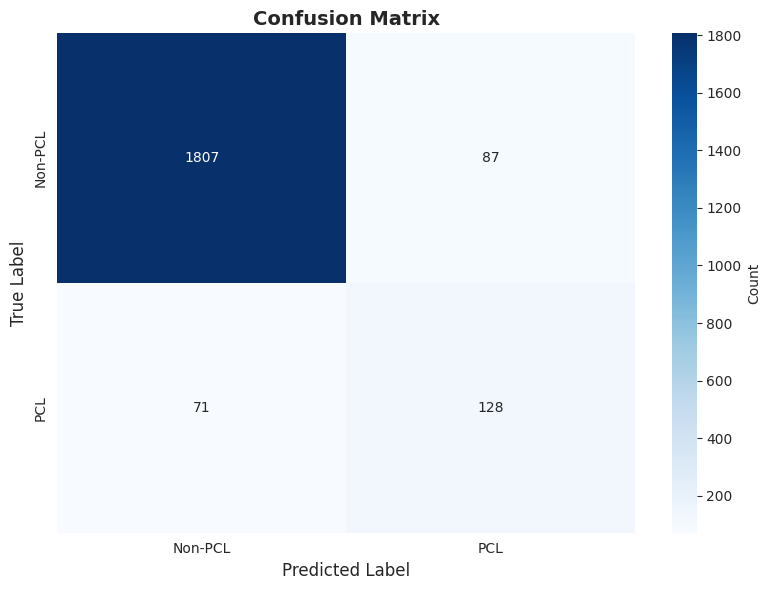

In [11]:
# Error distribution
print("=" * 70)
print("ERROR DISTRIBUTION")
print("=" * 70)

error_counts = dev_data['error_type'].value_counts()
print(f"\n{error_counts}\n")

# Detailed metrics
cm = confusion_matrix(true_labels, pred_labels)
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (Correct Non-PCL):  {tn:4d} ({tn/len(dev_data)*100:5.1f}%)")
print(f"True Positives (Correct PCL):      {tp:4d} ({tp/len(dev_data)*100:5.1f}%)")
print(f"False Positives (Wrong PCL):       {fp:4d} ({fp/len(dev_data)*100:5.1f}%)")
print(f"False Negatives (Missed PCL):      {fn:4d} ({fn/len(dev_data)*100:5.1f}%)")

print(f"\nPrecision: {tp/(tp+fp):.4f}")
print(f"Recall:    {tp/(tp+fn):.4f}")
print(f"F1 Score:  {f1_score(true_labels, pred_labels, pos_label=1):.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-PCL', 'PCL'],
            yticklabels=['Non-PCL', 'PCL'],
            ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Analyze False Negatives (Missed PCL)
print("=" * 70)
print("FALSE NEGATIVES ANALYSIS (Model missed these PCL cases)")
print("=" * 70)

fn_data = dev_data[dev_data['error_type'] == 'False Negative'].copy()
print(f"\nTotal False Negatives: {len(fn_data)}")
print(f"Average confidence when wrong: {fn_data['confidence'].mean():.3f}")
print(f"Average text length: {fn_data['text_length'].mean():.1f} chars")
print(f"Average word count: {fn_data['word_count'].mean():.1f} words")

# Show examples
print("\n--- Examples of False Negatives (sorted by confidence) ---\n")
fn_examples = fn_data.nlargest(5, 'confidence')[['text', 'pred_prob_pcl', 'confidence', 'keyword']]
for idx, row in fn_examples.iterrows():
    print(f"Keyword: {row['keyword']}")
    print(f"Text: {row['text'][:200]}...")
    print(f"Predicted PCL prob: {row['pred_prob_pcl']:.3f} (Confidence: {row['confidence']:.3f})")
    print("-" * 70)

FALSE NEGATIVES ANALYSIS (Model missed these PCL cases)

Total False Negatives: 71
Average confidence when wrong: 0.939
Average text length: 314.4 chars
Average word count: 58.0 words

--- Examples of False Negatives (sorted by confidence) ---

Keyword: disabled
Text: Cheung said 20 disabled undergraduate students from seven universities will start their eight-week internship in government departments this month , receiving the same salaries as able-bodied colleagu...
Predicted PCL prob: 0.001 (Confidence: 0.999)
----------------------------------------------------------------------
Keyword: poor-families
Text: The World Health Organization did not give a reason for the increase in deaths , but a provincial health official in Sindh said that the disease hit areas where poor families did not vaccinate their c...
Predicted PCL prob: 0.001 (Confidence: 0.999)
----------------------------------------------------------------------
Keyword: poor-families
Text: A top health official said toda

In [13]:
# Analyze False Positives
print("=" * 70)
print("FALSE POSITIVES ANALYSIS (Model incorrectly labeled as PCL)")
print("=" * 70)

fp_data = dev_data[dev_data['error_type'] == 'False Positive'].copy()
print(f"\nTotal False Positives: {len(fp_data)}")
print(f"Average confidence when wrong: {fp_data['confidence'].mean():.3f}")
print(f"Average text length: {fp_data['text_length'].mean():.1f} chars")
print(f"Average word count: {fp_data['word_count'].mean():.1f} words")

# Show examples
print("\n--- Examples of False Positives (sorted by confidence) ---\n")
fp_examples = fp_data.nlargest(5, 'confidence')[['text', 'pred_prob_pcl', 'confidence', 'keyword']]
for idx, row in fp_examples.iterrows():
    print(f"Keyword: {row['keyword']}")
    print(f"Text: {row['text'][:200]}...")
    print(f"Predicted PCL prob: {row['pred_prob_pcl']:.3f} (Confidence: {row['confidence']:.3f})")
    print("-" * 70)

FALSE POSITIVES ANALYSIS (Model incorrectly labeled as PCL)

Total False Positives: 87
Average confidence when wrong: 0.874
Average text length: 277.5 chars
Average word count: 51.0 words

--- Examples of False Positives (sorted by confidence) ---

Keyword: poor-families
Text: " We have identified extremely poor families , orphaned children , the elderly and those living with HIV/AIDS but with no source of income . We will give them priority to enable them get treated whene...
Predicted PCL prob: 0.995 (Confidence: 0.995)
----------------------------------------------------------------------
Keyword: hopeless
Text: But more than taking personal strength from the heroines of Philippine culture , Alma finds greater inspiration in being able to share her skills to build on the dreams of women and children , " I loo...
Predicted PCL prob: 0.994 (Confidence: 0.994)
----------------------------------------------------------------------
Keyword: in-need
Text: " I always consider this job as a

## 3. Text Length and Keyword Analysis

Investigating performance patterns across different text lengths and keywords.

TEXT LENGTH ANALYSIS

Performance by text length:

<100 chars:
  Samples: 146
  Accuracy: 0.918
  F1 Score: 0.571
  PCL samples: 11

100-200 chars:
  Samples: 664
  Accuracy: 0.934
  F1 Score: 0.656
  PCL samples: 54

200-300 chars:
  Samples: 687
  Accuracy: 0.945
  F1 Score: 0.661
  PCL samples: 59

300-500 chars:
  Samples: 453
  Accuracy: 0.890
  F1 Score: 0.537
  PCL samples: 57

>500 chars:
  Samples: 143
  Accuracy: 0.902
  F1 Score: 0.632
  PCL samples: 18


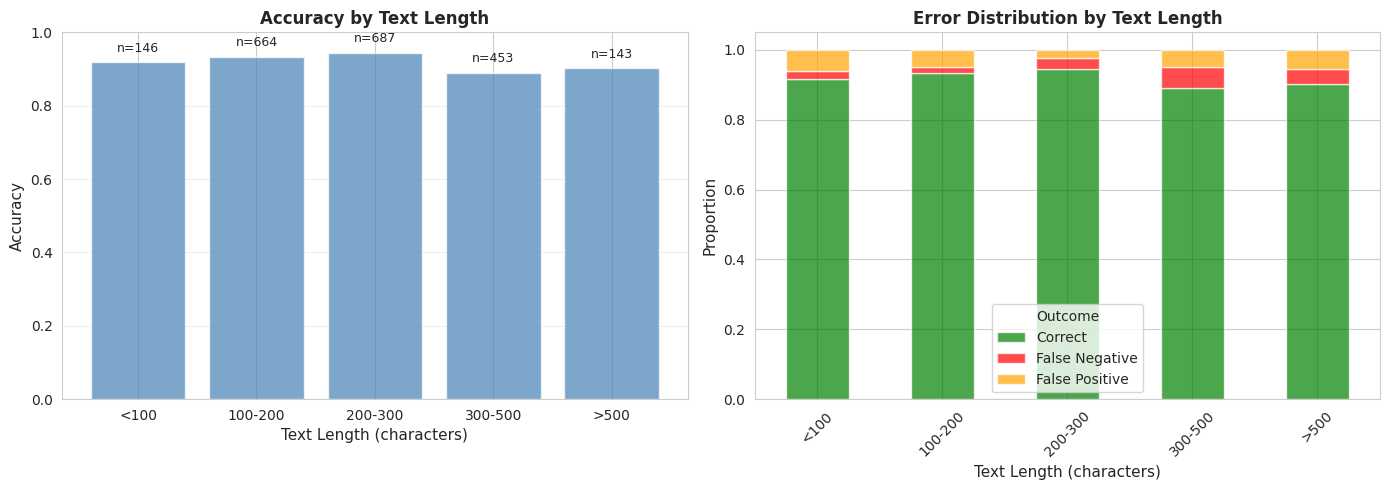

In [15]:
# Text length analysis
print("=" * 70)
print("TEXT LENGTH ANALYSIS")
print("=" * 70)

# Bin text lengths
dev_data['length_bin'] = pd.cut(dev_data['text_length'], 
                                 bins=[0, 100, 200, 300, 500, 10000],
                                 labels=['<100', '100-200', '200-300', '300-500', '>500'])

print("\nPerformance by text length:")
for length_bin in ['<100', '100-200', '200-300', '300-500', '>500']:
    subset = dev_data[dev_data['length_bin'] == length_bin]
    if len(subset) > 0:
        correct = (subset['predicted'] == subset['true_label']).sum()
        accuracy = correct / len(subset)
        
        # F1 for this subset
        if len(subset[subset['true_label'] == 1]) > 0:
            f1 = f1_score(subset['true_label'], subset['predicted'], pos_label=1, zero_division=0)
        else:
            f1 = 0.0
        
        print(f"\n{length_bin} chars:")
        print(f"  Samples: {len(subset)}")
        print(f"  Accuracy: {accuracy:.3f}")
        print(f"  F1 Score: {f1:.3f}")
        print(f"  PCL samples: {(subset['true_label']==1).sum()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy by length
ax = axes[0]
length_stats = []
for length_bin in ['<100', '100-200', '200-300', '300-500', '>500']:
    subset = dev_data[dev_data['length_bin'] == length_bin]
    if len(subset) > 0:
        accuracy = (subset['predicted'] == subset['true_label']).mean()
        length_stats.append({'length': length_bin, 'accuracy': accuracy, 'count': len(subset)})

length_df = pd.DataFrame(length_stats)
bars = ax.bar(length_df['length'], length_df['accuracy'], alpha=0.7, color='steelblue')
ax.set_xlabel('Text Length (characters)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy by Text Length', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3, axis='y')

# Add count labels
for bar, count in zip(bars, length_df['count']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'n={count}', ha='center', va='bottom', fontsize=9)

# Error type distribution by length
ax = axes[1]
error_by_length = dev_data.groupby(['length_bin', 'error_type']).size().unstack(fill_value=0)
error_by_length_pct = error_by_length.div(error_by_length.sum(axis=1), axis=0)
error_by_length_pct.plot(kind='bar', stacked=True, ax=ax, 
                          color=['green', 'red', 'orange'],
                          alpha=0.7)
ax.set_xlabel('Text Length (characters)', fontsize=11)
ax.set_ylabel('Proportion', fontsize=11)
ax.set_title('Error Distribution by Text Length', fontsize=12, fontweight='bold')
ax.legend(title='Outcome')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

KEYWORD ANALYSIS

Top 10 keywords by F1 score:
      keyword  count  accuracy       f1  pcl_rate
      in-need    226  0.911504 0.743590  0.146018
   vulnerable    209  0.942584 0.727273  0.095694
poor-families    190  0.847368 0.632911  0.200000
    immigrant    218  0.981651 0.600000  0.032110
     hopeless    217  0.898618 0.592593  0.119816
     homeless    212  0.867925 0.575758  0.136792
     disabled    194  0.938144 0.538462  0.072165
      migrant    206  0.980583 0.500000  0.024272
        women    233  0.948498 0.454545  0.060086
      refugee    188  0.920213 0.444444  0.069149


Bottom 10 keywords by F1 score:
      keyword  count  accuracy       f1  pcl_rate
      in-need    226  0.911504 0.743590  0.146018
   vulnerable    209  0.942584 0.727273  0.095694
poor-families    190  0.847368 0.632911  0.200000
    immigrant    218  0.981651 0.600000  0.032110
     hopeless    217  0.898618 0.592593  0.119816
     homeless    212  0.867925 0.575758  0.136792
     disabled    19

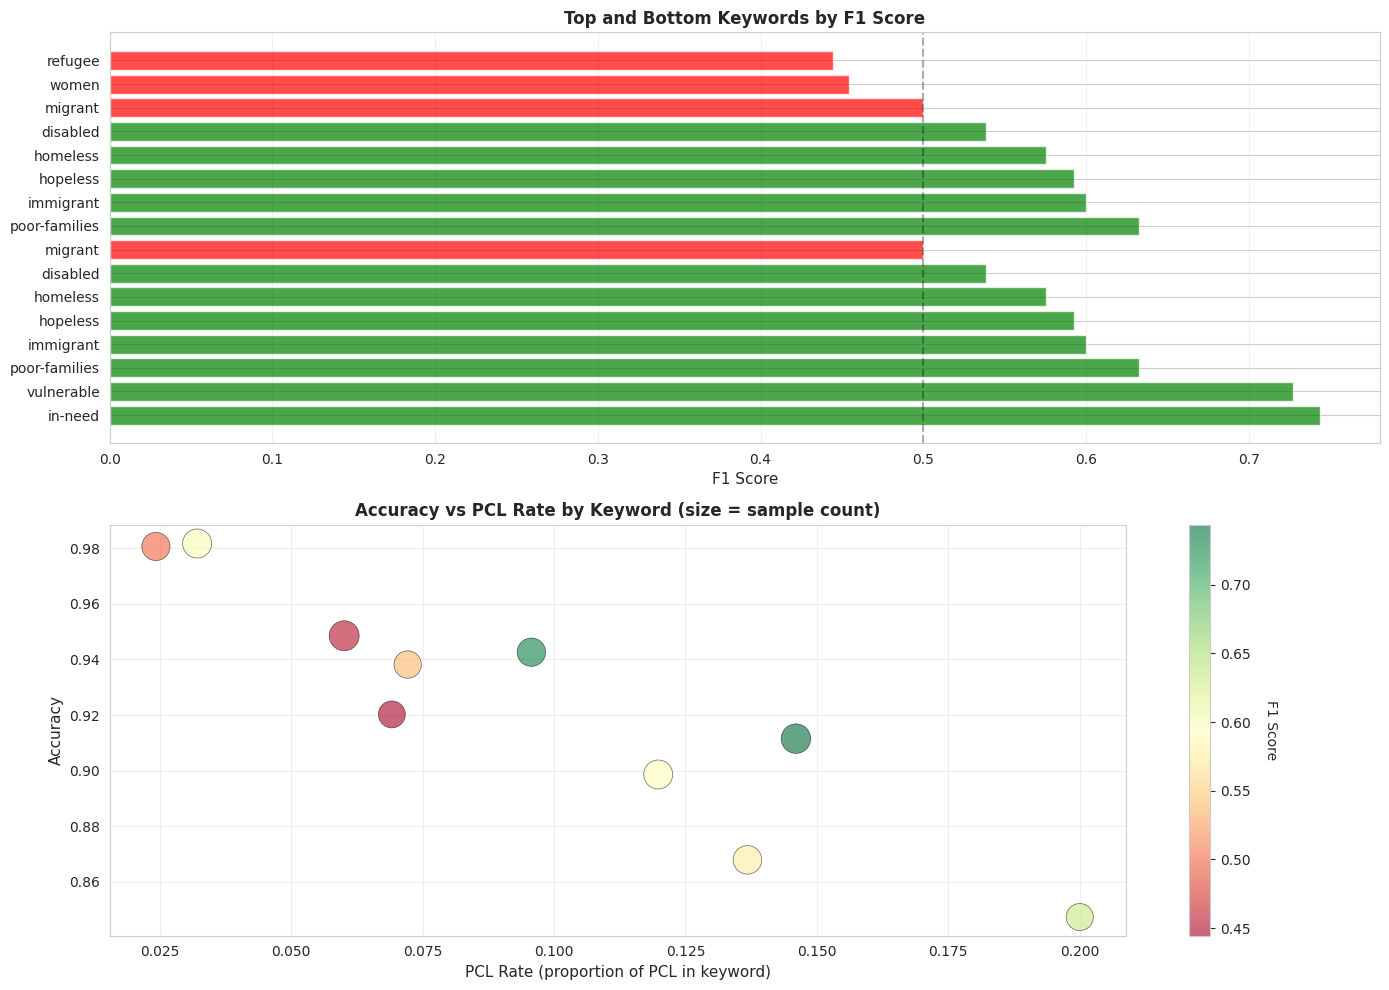

In [16]:
# Keyword analysis
print("=" * 70)
print("KEYWORD ANALYSIS")
print("=" * 70)

# Performance by keyword
keyword_stats = []
for keyword in dev_data['keyword'].unique():
    subset = dev_data[dev_data['keyword'] == keyword]
    if len(subset) >= 10:  # Only keywords with sufficient samples
        accuracy = (subset['predicted'] == subset['true_label']).mean()
        
        # Calculate F1 if there are positive samples
        if len(subset[subset['true_label'] == 1]) > 0:
            f1 = f1_score(subset['true_label'], subset['predicted'], pos_label=1, zero_division=0)
        else:
            f1 = 0.0
        
        pcl_rate = (subset['true_label'] == 1).mean()
        
        keyword_stats.append({
            'keyword': keyword,
            'count': len(subset),
            'accuracy': accuracy,
            'f1': f1,
            'pcl_rate': pcl_rate,
            'pcl_count': (subset['true_label'] == 1).sum()
        })

keyword_df = pd.DataFrame(keyword_stats).sort_values('f1', ascending=False)

print("\nTop 10 keywords by F1 score:")
print(keyword_df.head(10)[['keyword', 'count', 'accuracy', 'f1', 'pcl_rate']].to_string(index=False))

print("\n\nBottom 10 keywords by F1 score:")
print(keyword_df.tail(10)[['keyword', 'count', 'accuracy', 'f1', 'pcl_rate']].to_string(index=False))

# Visualize keyword performance
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top/bottom keywords by F1
ax = axes[0]
top_bottom = pd.concat([keyword_df.head(8), keyword_df.tail(8)])
colors = ['green' if f1 > 0.5 else 'red' for f1 in top_bottom['f1']]
bars = ax.barh(range(len(top_bottom)), top_bottom['f1'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_bottom)))
ax.set_yticklabels(top_bottom['keyword'])
ax.set_xlabel('F1 Score', fontsize=11)
ax.set_title('Top and Bottom Keywords by F1 Score', fontsize=12, fontweight='bold')
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.3)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 4. ROC Curve and Precision-Recall Analysis

Performance across different decision thresholds.

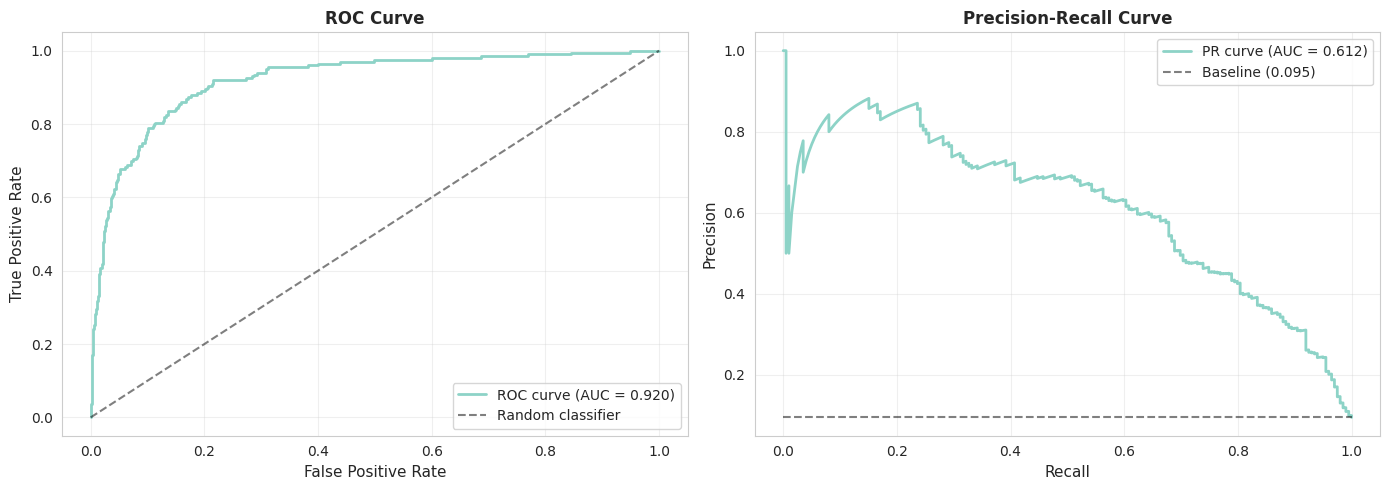

ROC AUC: 0.9198
PR AUC: 0.6124


In [17]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(true_labels, dev_data['pred_prob_pcl'])
roc_auc = auc(fpr, tpr)

ax = axes[0]
ax.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(true_labels, dev_data['pred_prob_pcl'])
pr_auc = auc(recall, precision)

ax = axes[1]
ax.plot(recall, precision, linewidth=2, label=f'PR curve (AUC = {pr_auc:.3f})')
# Baseline (proportion of positives)
baseline = true_labels.sum() / len(true_labels)
ax.plot([0, 1], [baseline, baseline], 'k--', alpha=0.5, label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")